# Topology Visualization

This notebook visualizes different network topologies including intra-node structures.

## 3-Level Hierarchy

The topology supports a 3-level hierarchy:
- **Server**: Generated by the inter-network topology (Dragonfly, FoldedClos, Jellyfish), connects to main switch via ToR
- **Nodes per Server**: Each server can have multiple nodes (controlled by `nodes_per_server`)
- **NPUs per Node**: Each node has multiple NPUs connected via intra-node topology (switch/ring/fully_connected)

**Structure**: NPUs -> NVSwitch/NPU-Switch -> NIC (ring/fc only) -> ToR -> Main Switch

## Visualization Features (bottom to top)
- **NPUs** (green): Processing units at level 0
- **NVSwitches/NPU-switches** (orange): Intra-node switches at level 1
- **NIC switches** (pink): For ring/fully_connected, connects node to ToR at level 2
- **ToR switches** (blue): Top-of-rack switches at level 3
- **Main switches** (purple): Topology switches at level 4
- Edge widths proportional to bandwidth

In [149]:
import sys
sys.path.insert(0, '/app/astra-sim/upc/create_topology/old')

import importlib
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Reload module to pick up any changes
import create_topology
importlib.reload(create_topology)
from create_topology import CustomizedDragonfly, FoldedClos, Jellyfish

In [ ]:
def classify_node(node_name, topology):
    """
    Classify a node into categories for proper positioning and coloring.
    Returns: 'npu', 'nvswitch', 'npu_switch', 'nic', 'tor', 'main_switch'
    
    Hierarchy levels:
    - npu: Processing units (bottom)
    - nvswitch/npu_switch: Intra-node switches connecting NPUs
    - nic: NIC switch connecting node to ToR (for ring/fully_connected)
    - tor: Top-of-Rack switch for a server
    - main_switch: Main topology switches (top)
    """
    if node_name.startswith('h'):
        return 'npu'
    
    # Check NVSwitch (for 'switch' topology)
    if hasattr(topology, 'nvswitch_ids') and node_name in topology.nvswitch_ids:
        return 'nvswitch'
    
    # Check NPU switches (for ring/fully_connected - internal switches)
    if hasattr(topology, 'npu_switches') and node_name in topology.npu_switches:
        return 'npu_switch'
    
    # Check NIC switches (for ring/fully_connected - connects to ToR)
    if hasattr(topology, 'nic_switches') and node_name in topology.nic_switches:
        return 'nic'
    
    # Check ToR switches
    if hasattr(topology, 'tor_switches') and node_name in topology.tor_switches:
        return 'tor'
    
    return 'main_switch'

IndentationError: unexpected indent (3218389816.py, line 20)

In [1]:
def create_hierarchical_layout(G, topology, width=10, height=8):
    """
    Create a hierarchical tree-like layout with:
    - NPUs at the bottom (level 0)
    - NVSwitches/NPU-switches above NPUs (level 1)
    - NIC switches above intra-node switches (level 2) - for ring/fully_connected
    - ToR switches above NICs (level 3)
    - Main switches at the top (level 4)
    """
    pos = {}
    
    # Classify all nodes
    npus = [n for n in G.nodes() if classify_node(n, topology) == 'npu']
    nvswitches = [n for n in G.nodes() if classify_node(n, topology) in ('nvswitch', 'npu_switch')]
    nics = [n for n in G.nodes() if classify_node(n, topology) == 'nic']
    tors = [n for n in G.nodes() if classify_node(n, topology) == 'tor']
    main_switches = [n for n in G.nodes() if classify_node(n, topology) == 'main_switch']
    
    # Define y-levels (bottom to top) - 5 levels now
    y_levels = {
        'npu': 0,
        'nvswitch': 1,
        'nic': 2,
        'tor': 3,
        'main_switch': 4
    }
    
    # Position each category
    def position_nodes(nodes, y_level):
        n = len(nodes)
        if n == 0:
            return
        # Sort nodes for consistent ordering
        sorted_nodes = sorted(nodes, key=lambda x: (x[0], int(x[1:]) if x[1:].isdigit() else 0))
        for i, node in enumerate(sorted_nodes):
            x = (i + 0.5) * width / n - width/2
            pos[node] = (x, y_level * height / 5)
    
    position_nodes(npus, y_levels['npu'])
    position_nodes(nvswitches, y_levels['nvswitch'])
    position_nodes(nics, y_levels['nic'])
    position_nodes(tors, y_levels['tor'])
    position_nodes(main_switches, y_levels['main_switch'])
    
    return pos

In [2]:
def build_topology(topology):
    """
    Build topology by calling the appropriate methods based on topology type.
    Different topology classes have different build methods.
    """
    # For Dragonfly and Jellyfish: need to call DesignFullTopology then LinksToG2ConfFile
    # For FoldedClos: just DesignFullTopology (it builds links internally)
    
    if hasattr(topology, 'DesignFullTopology'):
        topology.DesignFullTopology()
    
    # Dragonfly and Jellyfish need LinksToG2ConfFile to add host connections
    # LinksToG2ConfFile returns the full links dict but doesn't update self.links
    if hasattr(topology, 'LinksToG2ConfFile') and topology.name in ('dragonfly', 'jellyfish'):
        links = topology.LinksToG2ConfFile()
        topology.links = links  # Update self.links with the returned value


def visualize_topology(topology, title="Network Topology", figsize=(14, 10), show_bw=True):
    """
    Visualize a network topology with nodes, edges, names, and bandwidth labels.
    Uses hierarchical layout with intra-node elements at the bottom.
    """
    # Build the topology
    build_topology(topology)
    
    # Create graph
    G = nx.DiGraph()
    
    # Add nodes and edges from topology
    links = topology.links
    link_bws = topology.link_bandwidths
    
    for link_id, (src, dst) in links.items():
        G.add_edge(src, dst, bandwidth=link_bws.get(link_id, 1.0))
    
    # Create hierarchical layout
    pos = create_hierarchical_layout(G, topology, width=12, height=10)
    
    # Colors for different node types
    color_map = {
        'npu': '#4CAF50',         # Green
        'nvswitch': '#FF9800',    # Orange
        'npu_switch': '#FF9800',  # Orange (same as NVSwitch)
        'nic': '#E91E63',         # Pink (NIC connecting to ToR)
        'tor': '#2196F3',         # Blue
        'main_switch': '#9C27B0'  # Purple
    }
    
    node_colors = [color_map.get(classify_node(n, topology), '#757575') for n in G.nodes()]
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=800, ax=ax)
    
    # Draw edges with bandwidth as edge width (normalized)
    edges = G.edges()
    if edges:
        bws = [G[u][v]['bandwidth'] for u, v in edges]
        max_bw = max(bws) if bws else 1
        edge_widths = [1 + 3 * (bw / max_bw) for bw in bws]
        nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, 
                               width=edge_widths, alpha=0.7, ax=ax,
                               connectionstyle="arc3,rad=0.1")
    
    # Draw node labels
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold', ax=ax)
    
    # Draw edge bandwidth labels if requested
    if show_bw:
        edge_labels = {(u, v): f"{G[u][v]['bandwidth']:.1f}" for u, v in G.edges()}
        nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=7, ax=ax,
                                      label_pos=0.3)
    
    # Add legend
    legend_elements = [
        mpatches.Patch(color='#4CAF50', label='NPU'),
        mpatches.Patch(color='#FF9800', label='NVSwitch/NPU-Switch'),
        mpatches.Patch(color='#E91E63', label='NIC Switch'),
        mpatches.Patch(color='#2196F3', label='ToR Switch'),
        mpatches.Patch(color='#9C27B0', label='Main Switch')
    ]
    ax.legend(handles=legend_elements, loc='upper right')
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    
    return fig, ax, G

## Example 1: Small Dragonfly with NVSwitch Intra-node

2 groups, 2 switches per group, 1 node per switch, 4 NPUs per node, 1 NVSwitch

In [3]:
# Small dragonfly with NVSwitch topology
bw_config = {
    'host_switch': 100,       # Inter-node bandwidth (NPU to ToR)
    'intra_group': 200,       # Between switches in same group
    'inter_group': 50,        # Between groups
    'intra_node': 400         # Within node (NPU to NVSwitch)
}

df_nvswitch = CustomizedDragonfly(
    G=4,                      # 2 groups
    A=4,                      # 2 switches per group
    h=2,                      # 1 inter-pod link per switch
    concentration=2,          # 1 node per switch
    bandwidth_config=bw_config,
    npus_per_node=4,          # 4 NPUs per node
    intra_node_topology='switch',
    num_nvswitches=1
)

fig, ax, G = visualize_topology(df_nvswitch, "Dragonfly with NVSwitch Intra-node (1 NVSwitch)")
plt.show()

print(f"Total nodes: {G.number_of_nodes()}")
print(f"Total edges: {G.number_of_edges()}")

NameError: name 'CustomizedDragonfly' is not defined

## Example 2: Dragonfly with Multiple NVSwitches

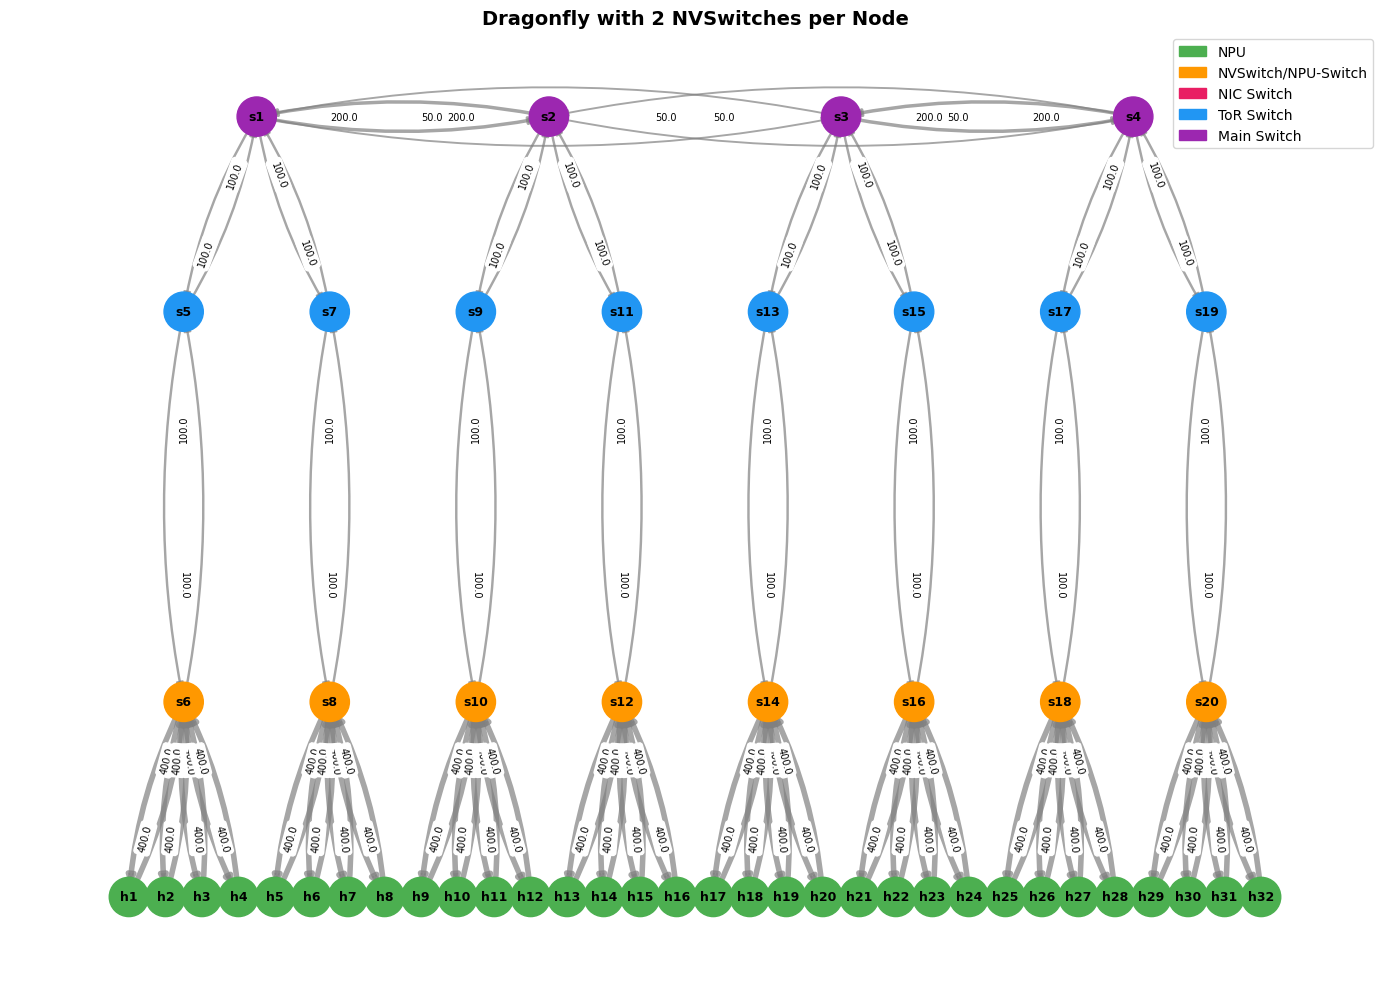

In [ ]:
# Dragonfly with 2 NVSwitches per node
bw_config = {
    'host_switch': 100,
    'intra_group': 200,
    'inter_group': 50,
    'intra_node': 400
}

df_multi_nv = CustomizedDragonfly(
    G=2,
    A=2,
    h=1,
    concentration=2,
    bandwidth_config=bw_config,
    npus_per_node=4,
    intra_node_topology='switch',
    num_nvswitches=1           # 2 NVSwitches
)

fig, ax, G = visualize_topology(df_multi_nv, "Dragonfly with 2 NVSwitches per Node")
plt.show()

## Example 3: Ring Intra-node Topology

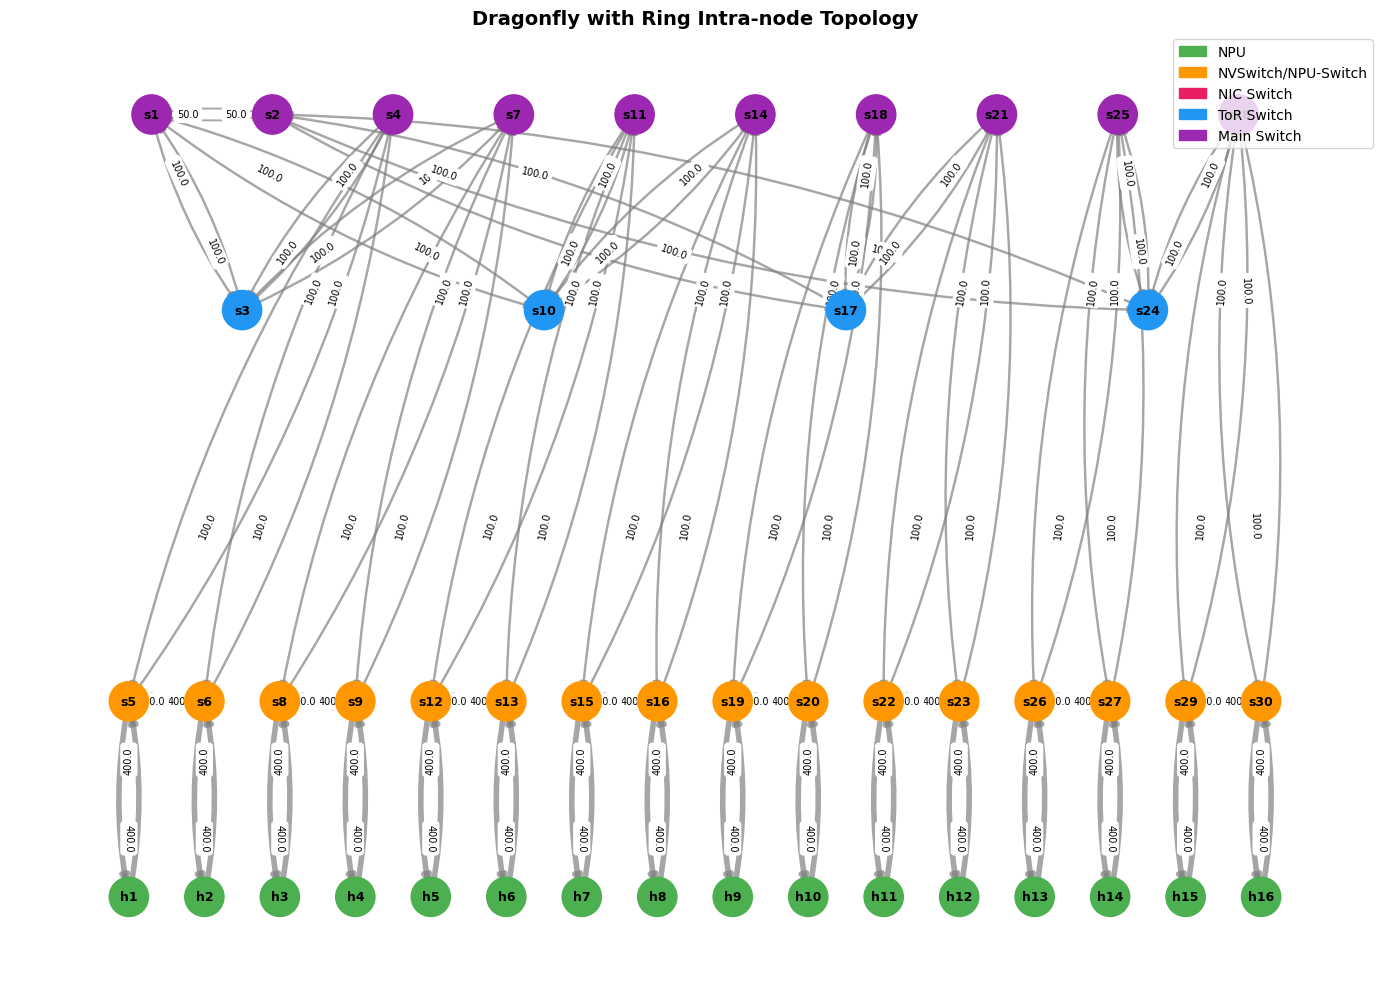

In [ ]:
# Dragonfly with Ring intra-node topology
bw_config = {
    'host_switch': 100,
    'intra_group': 200,
    'inter_group': 50,
    'intra_node': 400
}

df_ring = CustomizedDragonfly(
    G=2,
    A=1,                       # Smaller for clarity
    h=1,
    concentration=2,
    nodes_per_server=2,
    bandwidth_config=bw_config,
    npus_per_node=2,
    intra_node_topology='ring'
)

fig, ax, G = visualize_topology(df_ring, "Dragonfly with Ring Intra-node Topology")
plt.show()

## Example 4: Fully Connected Intra-node Topology

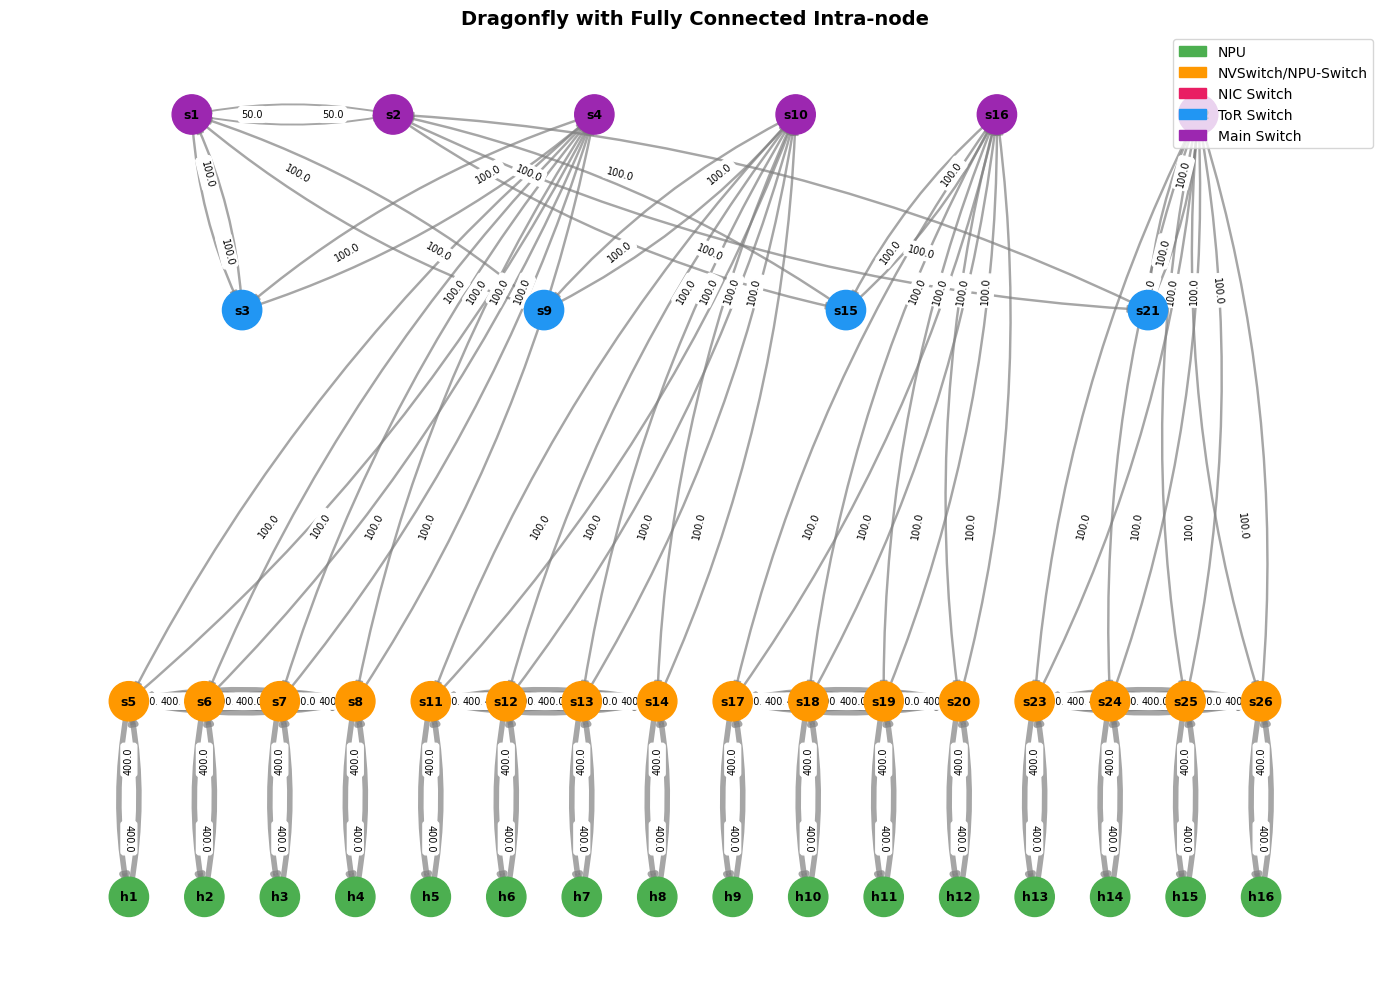

In [ ]:
# Dragonfly with Fully Connected intra-node topology
bw_config = {
    'host_switch': 100,
    'intra_group': 200,
    'inter_group': 50,
    'intra_node': 400
}

df_fc = CustomizedDragonfly(
    G=2,
    A=1,
    h=1,
    concentration=2,
    bandwidth_config=bw_config,
    nodes_per_server=1,
    npus_per_node=4,
    intra_node_topology='fully_connected'
)

fig, ax, G = visualize_topology(df_fc, "Dragonfly with Fully Connected Intra-node")
plt.show()

## Example 5: Single Node Detail View

Zoom in on just one node to see the NVSwitch structure clearly

In [ ]:
def visualize_single_node(topology, node_idx=1, figsize=(10, 8)):
    """
    Visualize just one node's internal structure.
    Shows NPUs -> NVSwitch(es) -> ToR hierarchy.
    node_idx is 1-based.
    """
    # Build the topology
    build_topology(topology)
    
    # Get NPUs for this node
    if not hasattr(topology, 'node_npus') or node_idx not in topology.node_npus:
        print(f"Node {node_idx} not found. Available nodes: {list(topology.node_npus.keys())[:5]}...")
        return
    
    npus = set(topology.node_npus[node_idx])
    tor = topology.tor_switches[node_idx - 1] if (node_idx - 1) < len(topology.tor_switches) else None
    
    # Get NVSwitches connected to these NPUs
    nvswitches = set()
    for npu in npus:
        if npu in topology.npu_to_intra_switches:
            nvswitches.update(topology.npu_to_intra_switches[npu])
    
    # Include ToR in relevant nodes
    relevant_nodes = npus | nvswitches | ({tor} if tor else set())
    
    G = nx.DiGraph()
    for link_id, (src, dst) in topology.links.items():
        if src in relevant_nodes and dst in relevant_nodes:
            bw = topology.link_bandwidths.get(link_id, 1.0)
            G.add_edge(src, dst, bandwidth=bw)
    
    # Manual hierarchical layout
    pos = {}
    
    # NPUs at bottom
    npu_list = sorted(npus)
    for i, npu in enumerate(npu_list):
        pos[npu] = ((i + 0.5) * 2 - len(npu_list), 0)
    
    # NVSwitches in middle
    nv_list = sorted(nvswitches)
    for i, nv in enumerate(nv_list):
        pos[nv] = ((i + 0.5) * 2 - len(nv_list), 1.5)
    
    # ToR at top
    if tor:
        pos[tor] = (0, 3)
    
    # Colors
    node_colors = []
    for n in G.nodes():
        if n in npus:
            node_colors.append('#4CAF50')
        elif n in nvswitches:
            node_colors.append('#FF9800')
        else:
            node_colors.append('#2196F3')
    
    fig, ax = plt.subplots(figsize=figsize)
    
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1500, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold', ax=ax)
    
    # Draw edges
    edges = list(G.edges())
    if edges:
        bws = [G[u][v]['bandwidth'] for u, v in edges]
        max_bw = max(bws) if bws else 1
        edge_widths = [1 + 4 * (bw / max_bw) for bw in bws]
        nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, 
                               width=edge_widths, alpha=0.7, ax=ax,
                               connectionstyle="arc3,rad=0.05")
    
    # Edge labels
    edge_labels = {(u, v): f"{G[u][v]['bandwidth']:.0f}" for u, v in G.edges()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=10, ax=ax)
    
    # Legend
    legend_elements = [
        mpatches.Patch(color='#4CAF50', label='NPU'),
        mpatches.Patch(color='#FF9800', label='NVSwitch'),
        mpatches.Patch(color='#2196F3', label='ToR Switch')
    ]
    ax.legend(handles=legend_elements, loc='upper right')
    
    ax.set_title(f"Single Node View (Node {node_idx})\nNPUs -> NVSwitch -> ToR", 
                 fontsize=14, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    
    return fig, ax

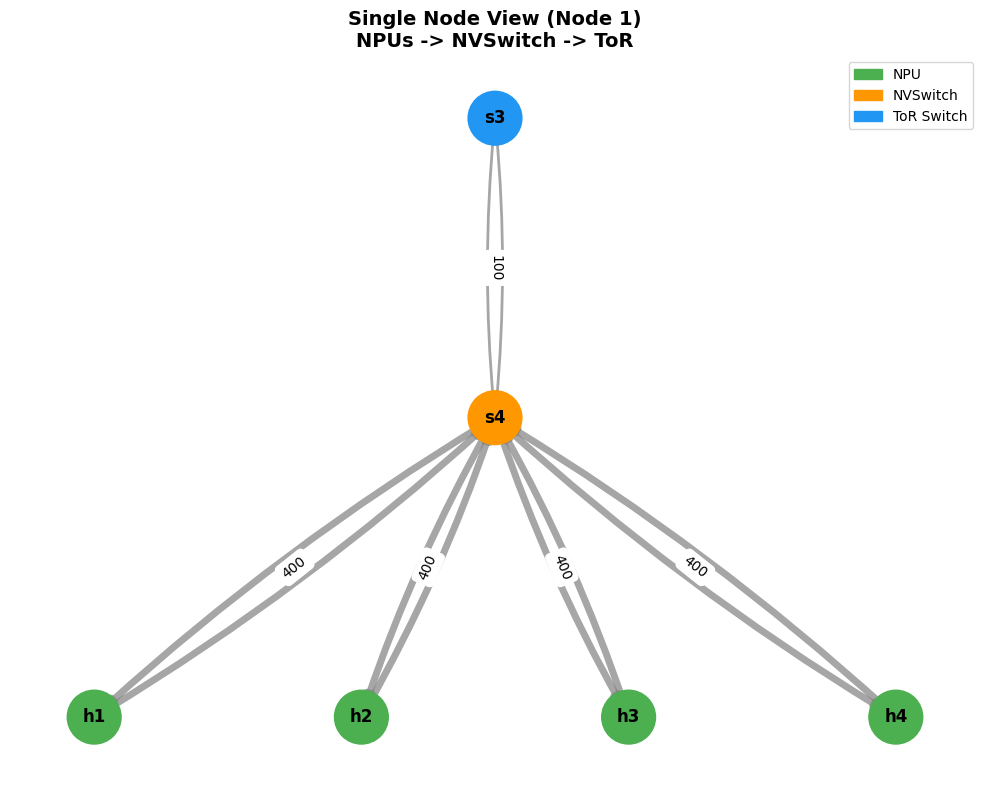


Topology structure:
NPUs: {1: ['h1', 'h2', 'h3', 'h4'], 2: ['h5', 'h6', 'h7', 'h8']}
NVSwitches: ['s4', 's6']
ToR switches: ['s3', 's5']


In [ ]:
# Visualize single node with 1 NVSwitch
# Note: node_idx is 1-based (node_npus uses 1-based keys)
bw_config = {
    'host_switch': 100,
    'intra_group': 200,
    'inter_group': 50,
    'intra_node': 400
}

df_single = CustomizedDragonfly(
    G=2, A=1, h=1, concentration=1,
    bandwidth_config=bw_config,
    npus_per_node=4,
    intra_node_topology='switch',
    num_nvswitches=1
)

visualize_single_node(df_single, node_idx=1)  # Use 1-based index
plt.show()

print("\nTopology structure:")
print(f"NPUs: {df_single.node_npus}")
print(f"NVSwitches: {df_single.nvswitch_ids}")
print(f"ToR switches: {df_single.tor_switches}")

In [ ]:
# Visualize single node with 2 NVSwitches
bw_config = {
    'host_switch': 100,
    'intra_group': 200,
    'inter_group': 50,
    'intra_node': 400
}

df_single_2nv = CustomizedDragonfly(
    G=1, A=1, h=1, concentration=1,
    bandwidth_config=bw_config,
    npus_per_node=4,
    intra_node_topology='switch',
    num_nvswitches=2
)

visualize_single_node(df_single_2nv, node_idx=0)
plt.show()

print("\nWith 2 NVSwitches - note bandwidth is split:")
print(f"NVSwitches: {df_single_2nv.nvswitch_ids}")

Node 0 not found. Available nodes: [1]...

With 2 NVSwitches - note bandwidth is split:
NVSwitches: ['s3', 's4']


## Verify the New Structure

Check that NVSwitches are connected to ToR (not NPUs directly to ToR)

In [ ]:
# Print detailed link information
bw_config = {
    'host_switch': 100,
    'intra_group': 200,
    'inter_group': 50,
    'intra_node': 400
}

topo = CustomizedDragonfly(
    G=1, A=1, h=1, concentration=1,
    bandwidth_config=bw_config,
    npus_per_node=4,
    intra_node_topology='switch',
    num_nvswitches=1
)
build_topology(topo)

print("Links in the topology:")
print("="*60)
print(f"{'Link ID':<10} {'Source':<10} {'Dest':<10} {'Bandwidth':<10}")
print("-"*60)

for link_id, (src, dst) in sorted(topo.links.items()):
    bw = topo.link_bandwidths.get(link_id, 'N/A')
    print(f"{link_id:<10} {src:<10} {dst:<10} {bw:<10}")

print("\n" + "="*60)
print("Verification:")
print(f"- ToR switches: {topo.tor_switches}")
print(f"- NVSwitches: {topo.nvswitch_ids}")
print(f"\nConnections to ToR (should be NVSwitches, not NPUs):")
for link_id, (src, dst) in topo.links.items():
    tor = topo.tor_switches[0] if topo.tor_switches else None
    if tor and (dst == tor or src == tor):
        print(f"  {src} <-> {dst} (bw: {topo.link_bandwidths.get(link_id)})")

Links in the topology:
Link ID    Source     Dest       Bandwidth 
------------------------------------------------------------
1          h1         s3         400.0     
2          s3         h1         400.0     
3          h2         s3         400.0     
4          s3         h2         400.0     
5          h3         s3         400.0     
6          s3         h3         400.0     
7          h4         s3         400.0     
8          s3         h4         400.0     
9          s3         s2         100       
10         s2         s3         100       
11         s2         s1         100       
12         s1         s2         100       

Verification:
- ToR switches: ['s2']
- NVSwitches: ['s3']

Connections to ToR (should be NVSwitches, not NPUs):
  s3 <-> s2 (bw: 100)
  s2 <-> s3 (bw: 100)
  s2 <-> s1 (bw: 100)
  s1 <-> s2 (bw: 100)


## Example 6: Folded-Clos (Fat-Tree) Topology

K=4 fat-tree with NVSwitch intra-node topology

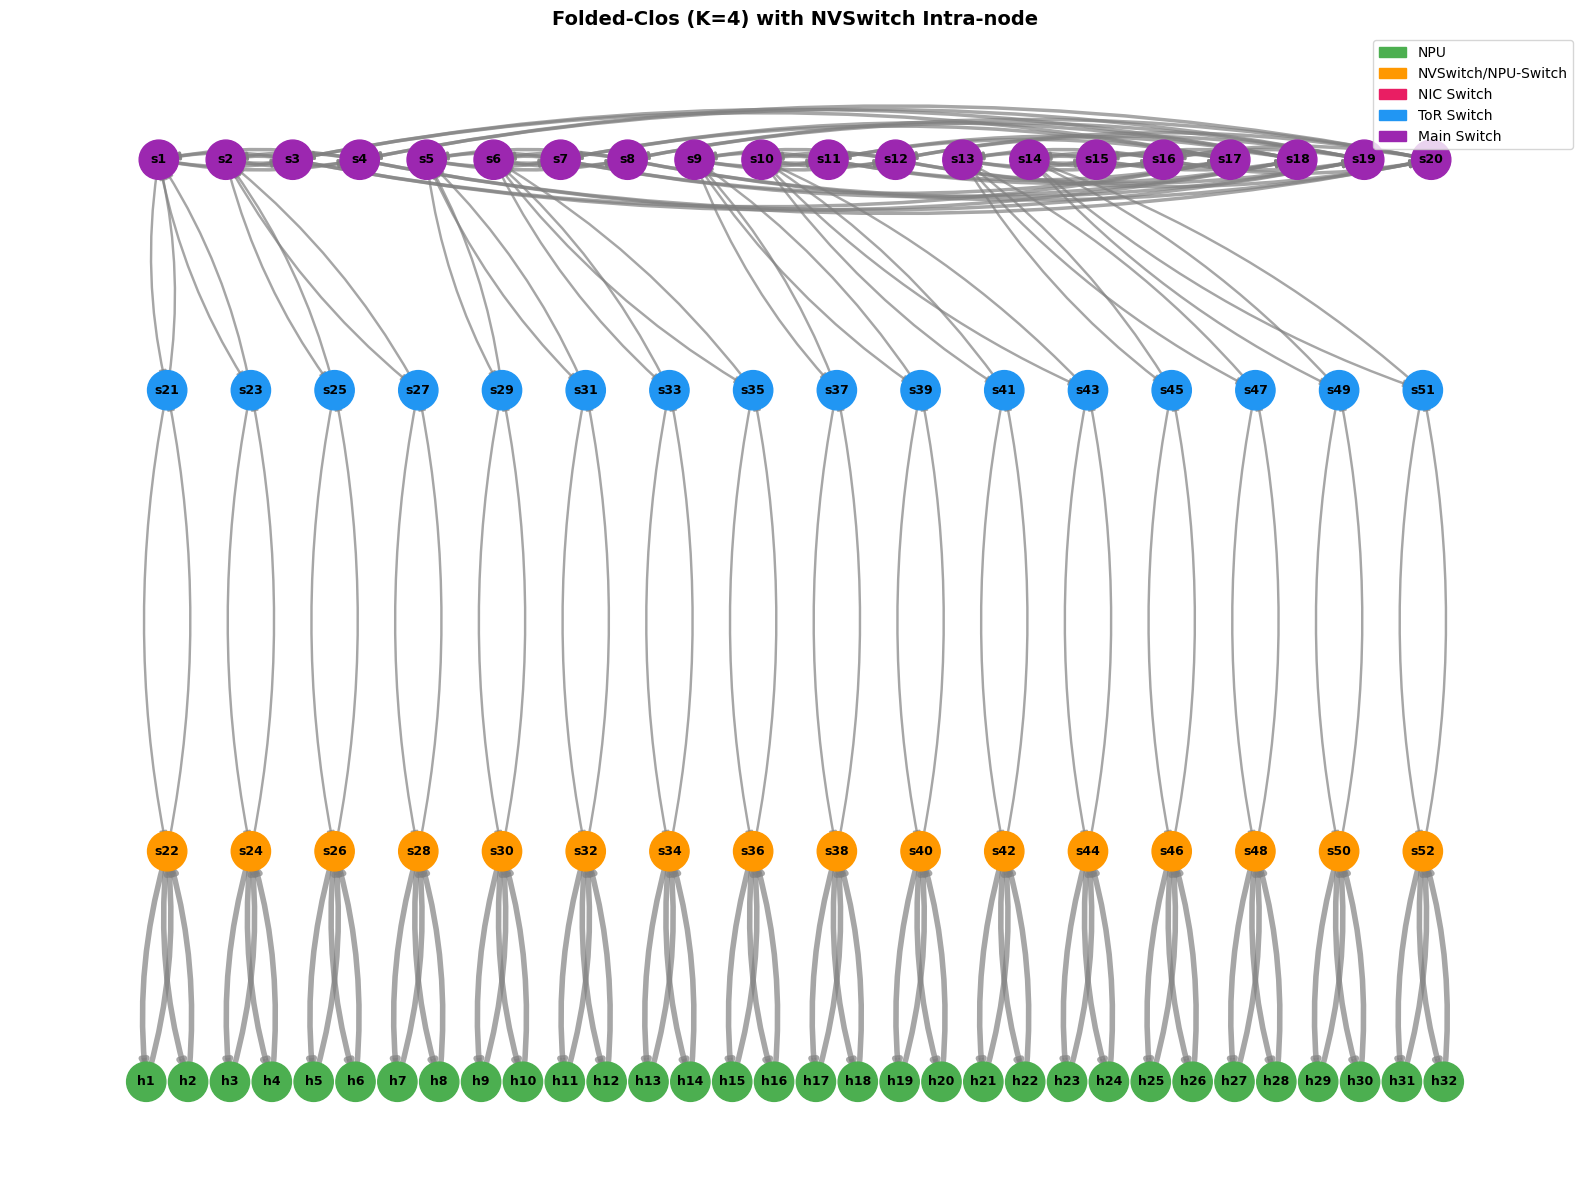

Total nodes: 84
Total edges: 192
NPUs: 32
ToR switches: ['s21', 's23', 's25', 's27']...


In [ ]:
# Folded-Clos (Fat-Tree) with NVSwitch topology
bw_config = {
    'host_edge': 100,         # Host to edge switch
    'edge_agg': 200,          # Edge to aggregation
    'agg_core': 200,          # Aggregation to core
    'intra_node': 400         # Within node (NPU to NVSwitch)
}

fc_nvswitch = FoldedClos(
    K=4,                      # K=4 fat-tree
    bandwidth_config=bw_config,
    npus_per_node=2,          # 2 NPUs per node (smaller for visibility)
    intra_node_topology='switch',
    num_nvswitches=1
)

fig, ax, G = visualize_topology(fc_nvswitch, "Folded-Clos (K=4) with NVSwitch Intra-node", figsize=(16, 12), show_bw=False)
plt.show()

print(f"Total nodes: {G.number_of_nodes()}")
print(f"Total edges: {G.number_of_edges()}")
print(f"NPUs: {len(fc_nvswitch.all_npus)}")
print(f"ToR switches: {fc_nvswitch.tor_switches[:4]}...")  # Show first few

## Example 7: Jellyfish Topology

Random graph topology with NVSwitch intra-node

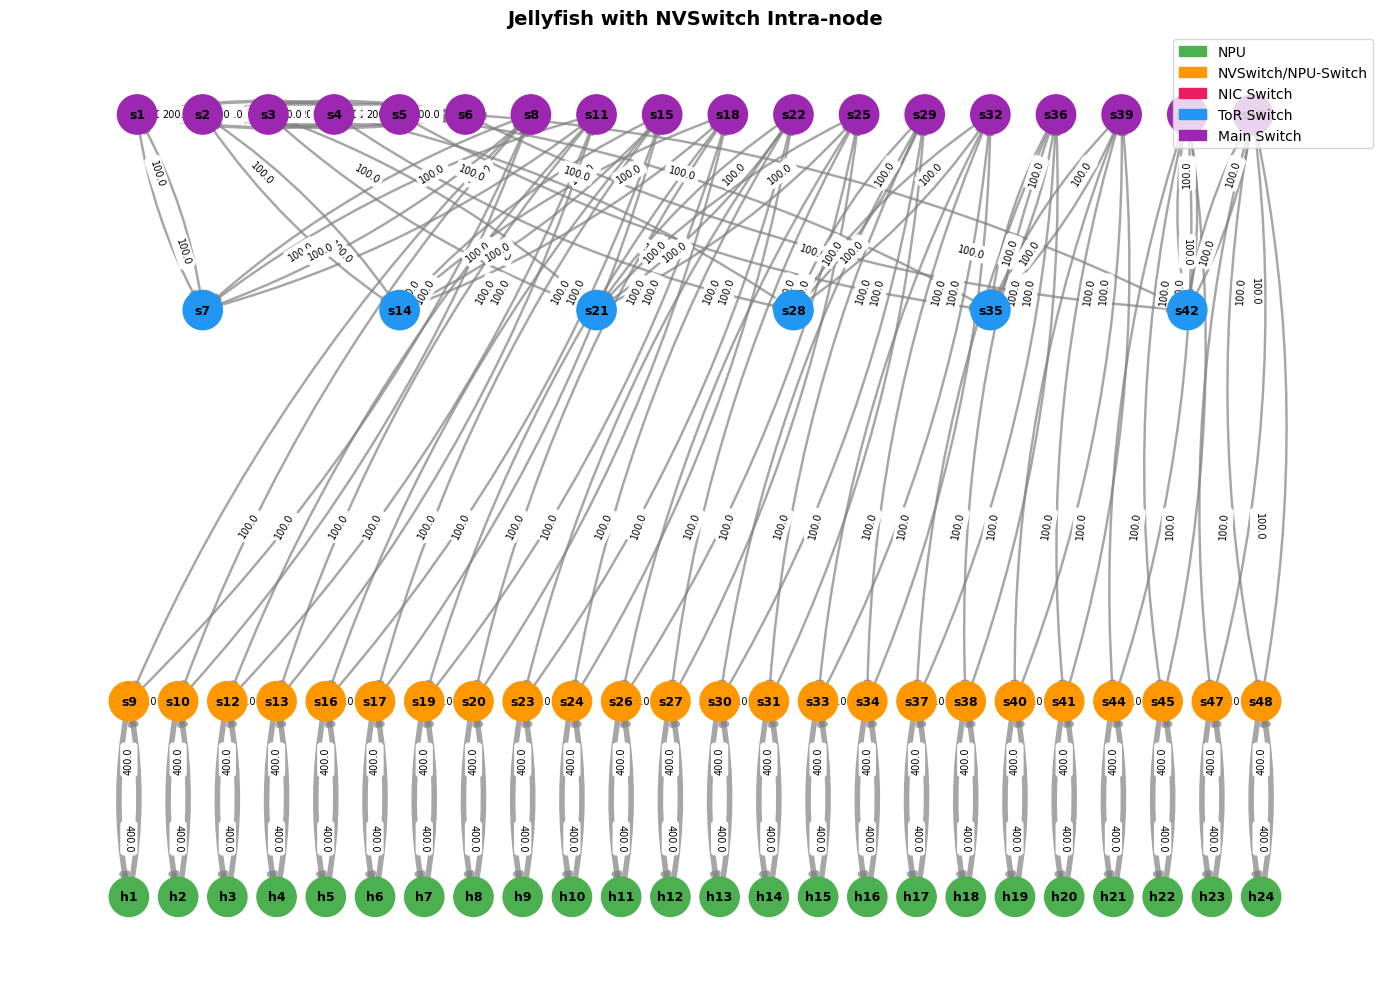

Total nodes: 72
Total edges: 174
NPUs: 24
NVSwitches: []


In [ ]:
# Jellyfish with NVSwitch topology
bw_config = {
    'host_switch': 100,       # Host to switch
    'switch_switch': 200,     # Between switches
    'intra_node': 400         # Within node (NPU to NVSwitch)
}

jf_nvswitch = Jellyfish(
    num_switches=6,           # 6 switches
    degree=3,                 # Each switch connects to 3 others
    num_hosts_per_switch=1,   # 1 node per switch
    bandwidth_config=bw_config,
    nodes_per_server=2,
    npus_per_node=2,          # 4 NPUs per node
    intra_node_topology='fully_connected',
    # num_nvswitches=1
)

fig, ax, G = visualize_topology(jf_nvswitch, "Jellyfish with NVSwitch Intra-node", figsize=(14, 10))
plt.show()

print(f"Total nodes: {G.number_of_nodes()}")
print(f"Total edges: {G.number_of_edges()}")
print(f"NPUs: {len(jf_nvswitch.all_npus)}")
print(f"NVSwitches: {jf_nvswitch.nvswitch_ids}")

## Example 8: Single Node View - Folded-Clos

Visualize just one node from a FoldedClos topology to see the NVSwitch -> ToR structure

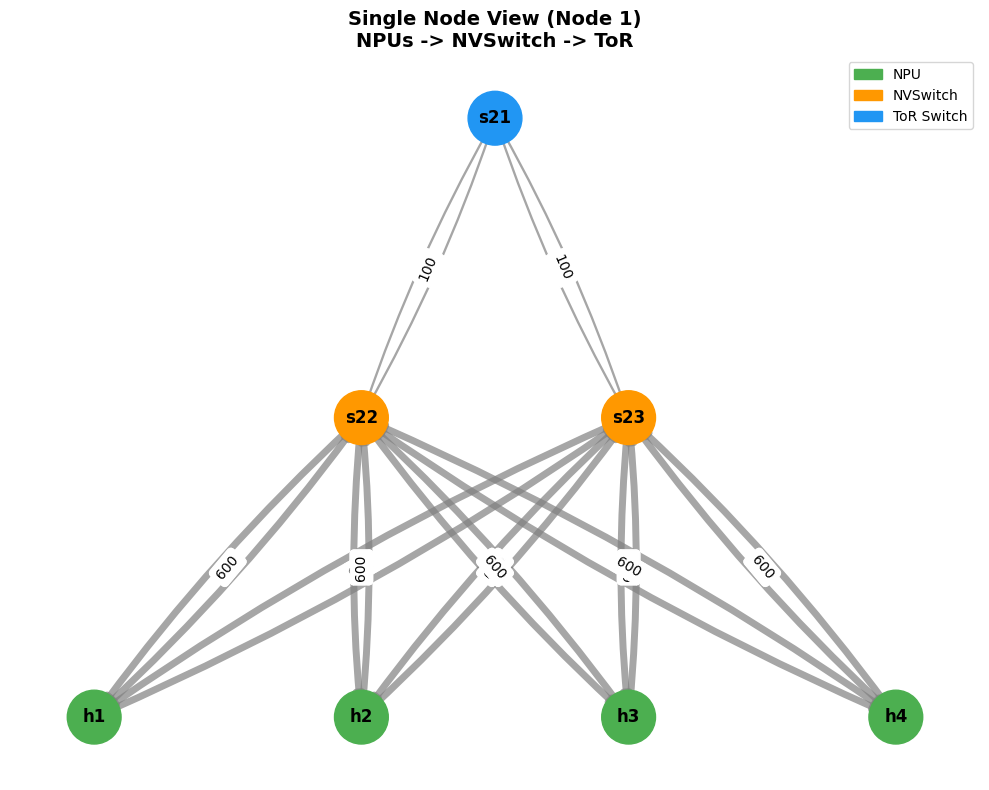


Node structure with 2 NVSwitches:
NVSwitches: ['s22', 's23', 's25', 's26']...
Intra-node BW per NVSwitch: 300.0


In [ ]:
# Single node view from Folded-Clos with 2 NVSwitches
bw_config = {
    'host_edge': 100,
    'edge_agg': 200,
    'agg_core': 200,
    'intra_node': 600  # High intra-node bandwidth
}

fc_single = FoldedClos(
    K=4,
    bandwidth_config=bw_config,
    npus_per_node=4,
    intra_node_topology='switch',
    num_nvswitches=2  # 2 NVSwitches
)

visualize_single_node(fc_single, node_idx=1)
plt.show()

print("\nNode structure with 2 NVSwitches:")
print(f"NVSwitches: {fc_single.nvswitch_ids[:4]}...")
print(f"Intra-node BW per NVSwitch: {bw_config['intra_node'] / 2}")  # Split among NVSwitches

## Example 9: 3-Level Hierarchy (Server -> Nodes -> NPUs)

This example demonstrates the new `nodes_per_server` parameter which creates a 3-level hierarchy:
- **Server**: connects to the main switch (via ToR)
- **Nodes**: multiple nodes per server, each with its own NVSwitch(es)
- **NPUs**: multiple NPUs per node

Structure: NPUs -> NVSwitch -> ToR -> Main Switch

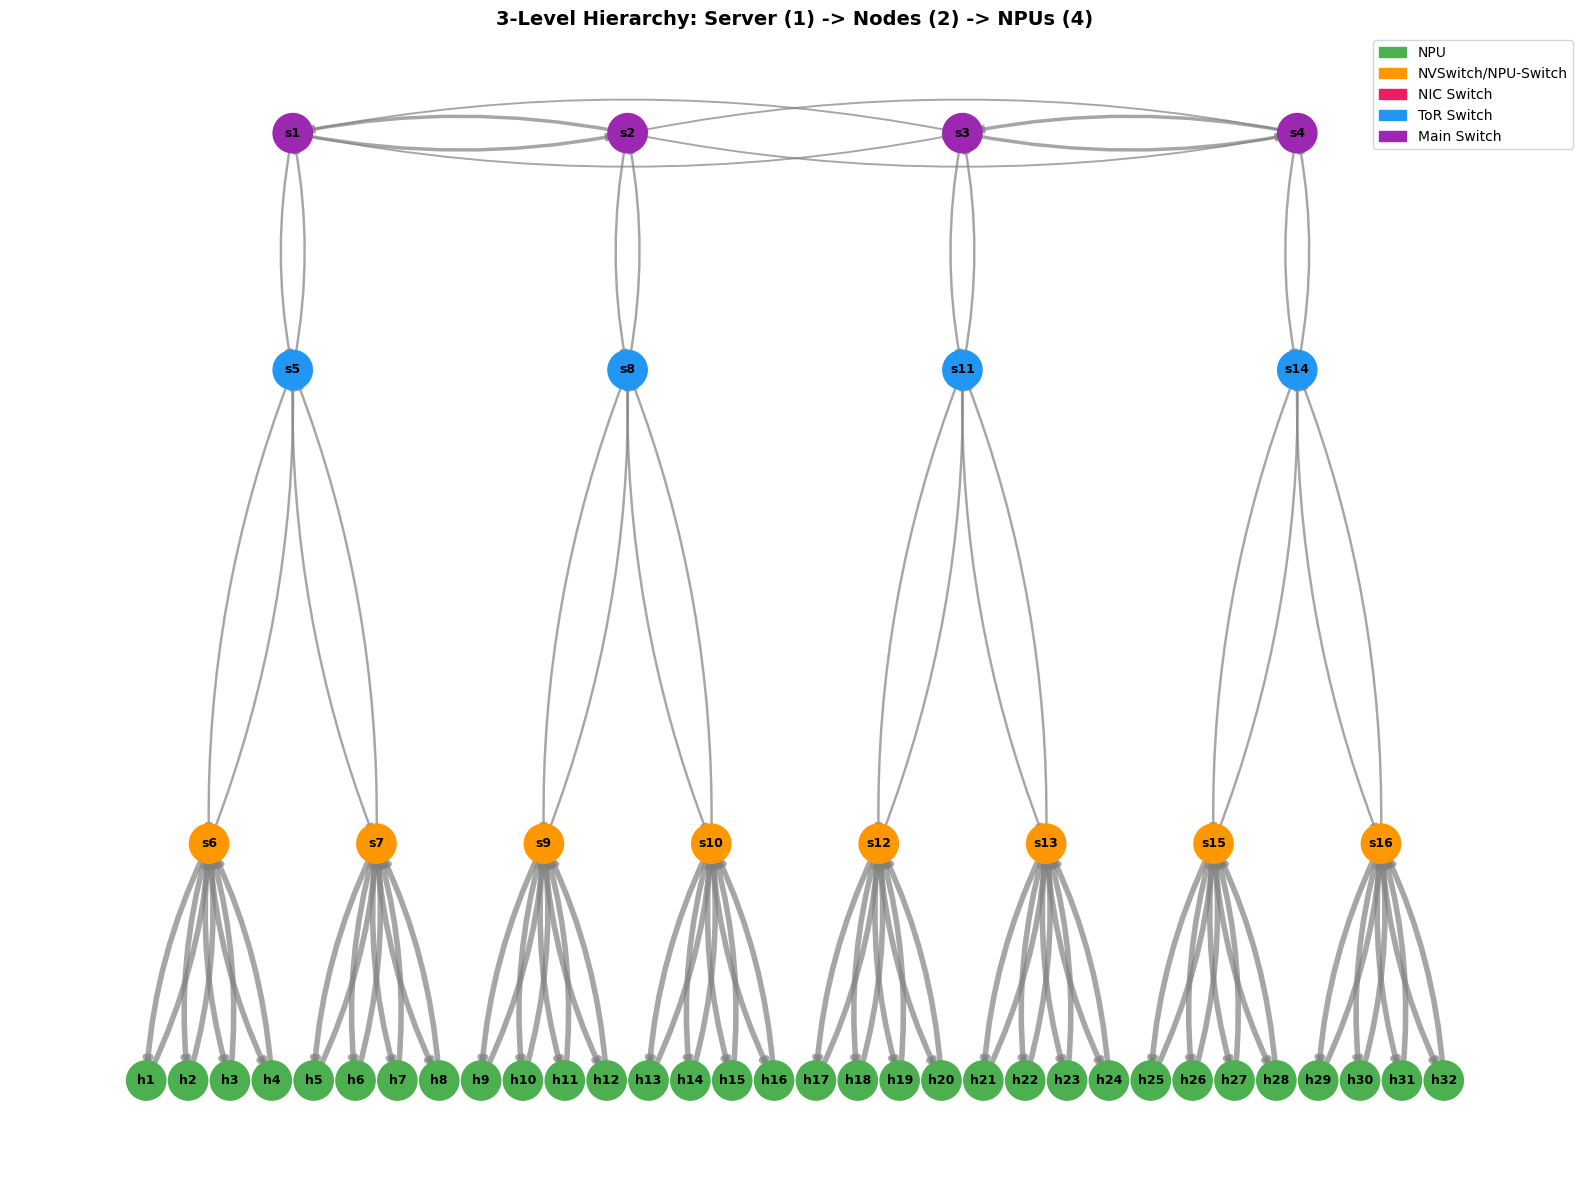

Configuration:
  - Main switches: 4
  - Servers (total): 4
  - Nodes per server: 2
  - Total nodes: 8
  - NPUs per node: 4
  - Total NPUs: 32

Hierarchy mapping:
  - server_nodes: {1: [1, 2], 2: [3, 4]}...
  - node_npus: {1: ['h1', 'h2', 'h3', 'h4'], 2: ['h5', 'h6', 'h7', 'h8']}...


In [ ]:
# 3-Level Hierarchy: Server -> Nodes -> NPUs
bw_config = {
    'host_switch': 100,       # Inter-node bandwidth (Node to ToR)
    'intra_group': 200,       # Between switches in same group
    'inter_group': 50,        # Between groups
    'intra_node': 400         # Within node (NPU to NVSwitch)
}

# Create topology with:
# - 2 groups, 2 switches per group
# - 2 servers per switch
# - 2 nodes per server (NEW!)
# - 4 NPUs per node
# - NVSwitch connecting NPUs within each node
df_3level = CustomizedDragonfly(
    G=2,                      # 2 groups
    A=2,                      # 2 switches per group
    h=1,                      # 1 inter-group link per switch
    concentration=1,          # 1 server per switch
    bandwidth_config=bw_config,
    nodes_per_server=2,       # NEW: 2 nodes per server
    npus_per_node=4,          # 4 NPUs per node
    intra_node_topology='switch',
    num_nvswitches=1
)

fig, ax, G = visualize_topology(df_3level, 
    "3-Level Hierarchy: Server (1) -> Nodes (2) -> NPUs (4)", 
    figsize=(16, 12), show_bw=False)
plt.show()

print(f"Configuration:")
print(f"  - Main switches: {df_3level.total_num_switches}")
print(f"  - Servers (total): {df_3level.total_num_servers}")
print(f"  - Nodes per server: {df_3level.nodes_per_server}")
print(f"  - Total nodes: {df_3level.total_num_nodes}")
print(f"  - NPUs per node: {df_3level.npus_per_node}")
print(f"  - Total NPUs: {df_3level.total_num_hosts}")
print(f"\nHierarchy mapping:")
print(f"  - server_nodes: {dict(list(df_3level.server_nodes.items())[:2])}...")
print(f"  - node_npus: {dict(list(df_3level.node_npus.items())[:2])}...")

## Example 10: Single Server View (3-Level Hierarchy)

Visualize a single server with multiple nodes to see the full hierarchy:
NPUs -> NVSwitch(es) -> ToR

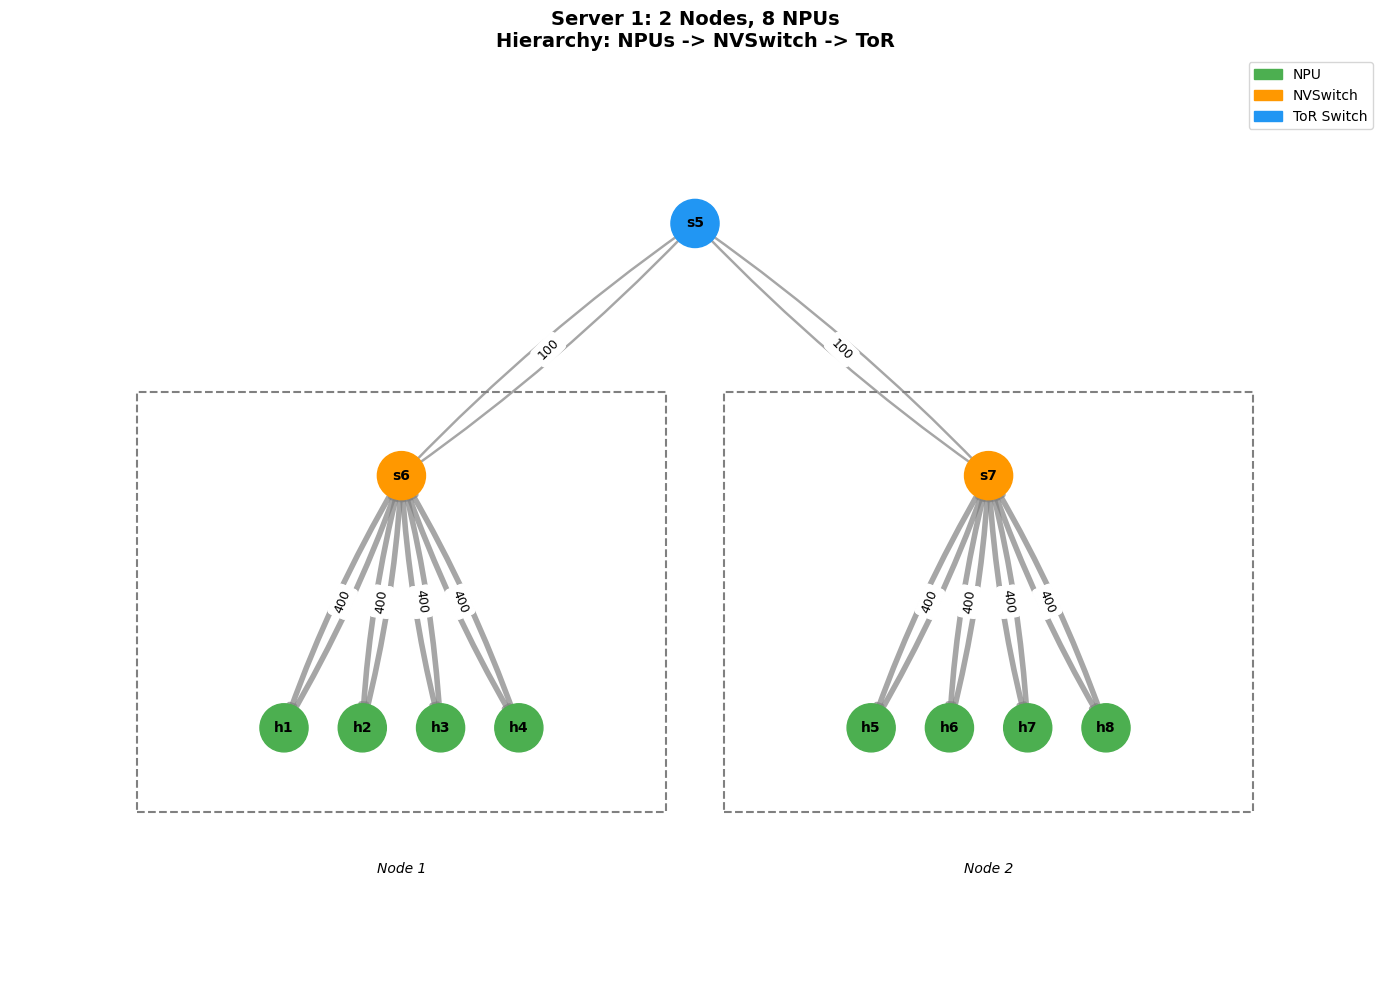


Server 1 contains:
  - Nodes: [1, 2]
  - Node 1 NPUs: ['h1', 'h2', 'h3', 'h4']
  - Node 2 NPUs: ['h5', 'h6', 'h7', 'h8']


In [ ]:
def visualize_single_server(topology, server_idx=1, figsize=(14, 10)):
    """
    Visualize a single server's structure showing all nodes and NPUs.
    Shows the 3-level hierarchy: NPUs -> NVSwitches -> ToR
    server_idx is 1-based.
    """
    # Build the topology
    build_topology(topology)
    
    # Check if server exists
    if not hasattr(topology, 'server_nodes') or server_idx not in topology.server_nodes:
        print(f"Server {server_idx} not found. Available servers: {list(topology.server_nodes.keys())[:5]}...")
        return
    
    # Get all nodes in this server
    node_ids = topology.server_nodes[server_idx]
    
    # Get ToR for this server
    tor = topology.server_to_tor.get(server_idx) if hasattr(topology, 'server_to_tor') else None
    
    # Collect all NPUs and NVSwitches for this server
    all_npus = set()
    all_nvswitches = set()
    for node_id in node_ids:
        if node_id in topology.node_npus:
            npus = topology.node_npus[node_id]
            all_npus.update(npus)
            for npu in npus:
                if npu in topology.npu_to_intra_switches:
                    all_nvswitches.update(topology.npu_to_intra_switches[npu])
    
    # All relevant nodes
    relevant_nodes = all_npus | all_nvswitches | ({tor} if tor else set())
    
    G = nx.DiGraph()
    for link_id, (src, dst) in topology.links.items():
        if src in relevant_nodes and dst in relevant_nodes:
            bw = topology.link_bandwidths.get(link_id, 1.0)
            G.add_edge(src, dst, bandwidth=bw)
    
    # Create hierarchical layout by node
    pos = {}
    num_nodes = len(node_ids)
    node_width = 12 / num_nodes if num_nodes > 0 else 12
    
    for node_offset, node_id in enumerate(node_ids):
        node_npus = topology.node_npus.get(node_id, [])
        node_center_x = (node_offset + 0.5) * node_width - 6
        
        # Position NPUs for this node
        for i, npu in enumerate(sorted(node_npus)):
            npu_x = node_center_x + (i - len(node_npus)/2 + 0.5) * 0.8
            pos[npu] = (npu_x, 0)
        
        # Position NVSwitches for this node
        node_nvswitches = set()
        for npu in node_npus:
            if npu in topology.npu_to_intra_switches:
                node_nvswitches.update(topology.npu_to_intra_switches[npu])
        
        for i, nvs in enumerate(sorted(node_nvswitches)):
            nvs_x = node_center_x + (i - len(node_nvswitches)/2 + 0.5) * 1.0
            pos[nvs] = (nvs_x, 1.5)
    
    # ToR at the top center
    if tor:
        pos[tor] = (0, 3)
    
    # Colors
    node_colors = []
    for n in G.nodes():
        if n in all_npus:
            node_colors.append('#4CAF50')
        elif n in all_nvswitches:
            node_colors.append('#FF9800')
        else:
            node_colors.append('#2196F3')
    
    fig, ax = plt.subplots(figsize=figsize)
    
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1200, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', ax=ax)
    
    # Draw edges
    edges = list(G.edges())
    if edges:
        bws = [G[u][v]['bandwidth'] for u, v in edges]
        max_bw = max(bws) if bws else 1
        edge_widths = [1 + 3 * (bw / max_bw) for bw in bws]
        nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, 
                               width=edge_widths, alpha=0.7, ax=ax,
                               connectionstyle="arc3,rad=0.05")
    
    # Edge labels
    edge_labels = {(u, v): f"{G[u][v]['bandwidth']:.0f}" for u, v in G.edges()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=9, ax=ax)
    
    # Legend
    legend_elements = [
        mpatches.Patch(color='#4CAF50', label='NPU'),
        mpatches.Patch(color='#FF9800', label='NVSwitch'),
        mpatches.Patch(color='#2196F3', label='ToR Switch')
    ]
    ax.legend(handles=legend_elements, loc='upper right')
    
    # Add node boundaries
    for node_offset, node_id in enumerate(node_ids):
        node_npus = topology.node_npus.get(node_id, [])
        if node_npus:
            node_center_x = (node_offset + 0.5) * node_width - 6
            rect = plt.Rectangle((node_center_x - node_width/2 + 0.3, -0.5), 
                                  node_width - 0.6, 2.5, 
                                  fill=False, linestyle='--', 
                                  edgecolor='gray', linewidth=1.5)
            ax.add_patch(rect)
            ax.text(node_center_x, -0.8, f"Node {node_id}", 
                    ha='center', va='top', fontsize=10, style='italic')
    
    ax.set_title(f"Server {server_idx}: {num_nodes} Nodes, {len(all_npus)} NPUs\n"
                 f"Hierarchy: NPUs -> NVSwitch -> ToR", 
                 fontsize=14, fontweight='bold')
    ax.axis('off')
    ax.set_xlim(-7, 7)
    ax.set_ylim(-1.5, 4)
    plt.tight_layout()
    
    return fig, ax

# Visualize server 1 from the 3-level hierarchy topology
visualize_single_server(df_3level, server_idx=1)
plt.show()

print(f"\nServer 1 contains:")
print(f"  - Nodes: {df_3level.server_nodes.get(1, [])}")
for node_id in df_3level.server_nodes.get(1, []):
    print(f"  - Node {node_id} NPUs: {df_3level.node_npus.get(node_id, [])}")

## Example 11: Folded-Clos with 3-Level Hierarchy

Fat-Tree topology with multiple nodes per server

Folded-Clos Configuration:
  - K: 4
  - Total servers: 16
  - Nodes per server: 4
  - Total nodes: 64
  - NPUs per node: 2
  - Total NPUs: 128


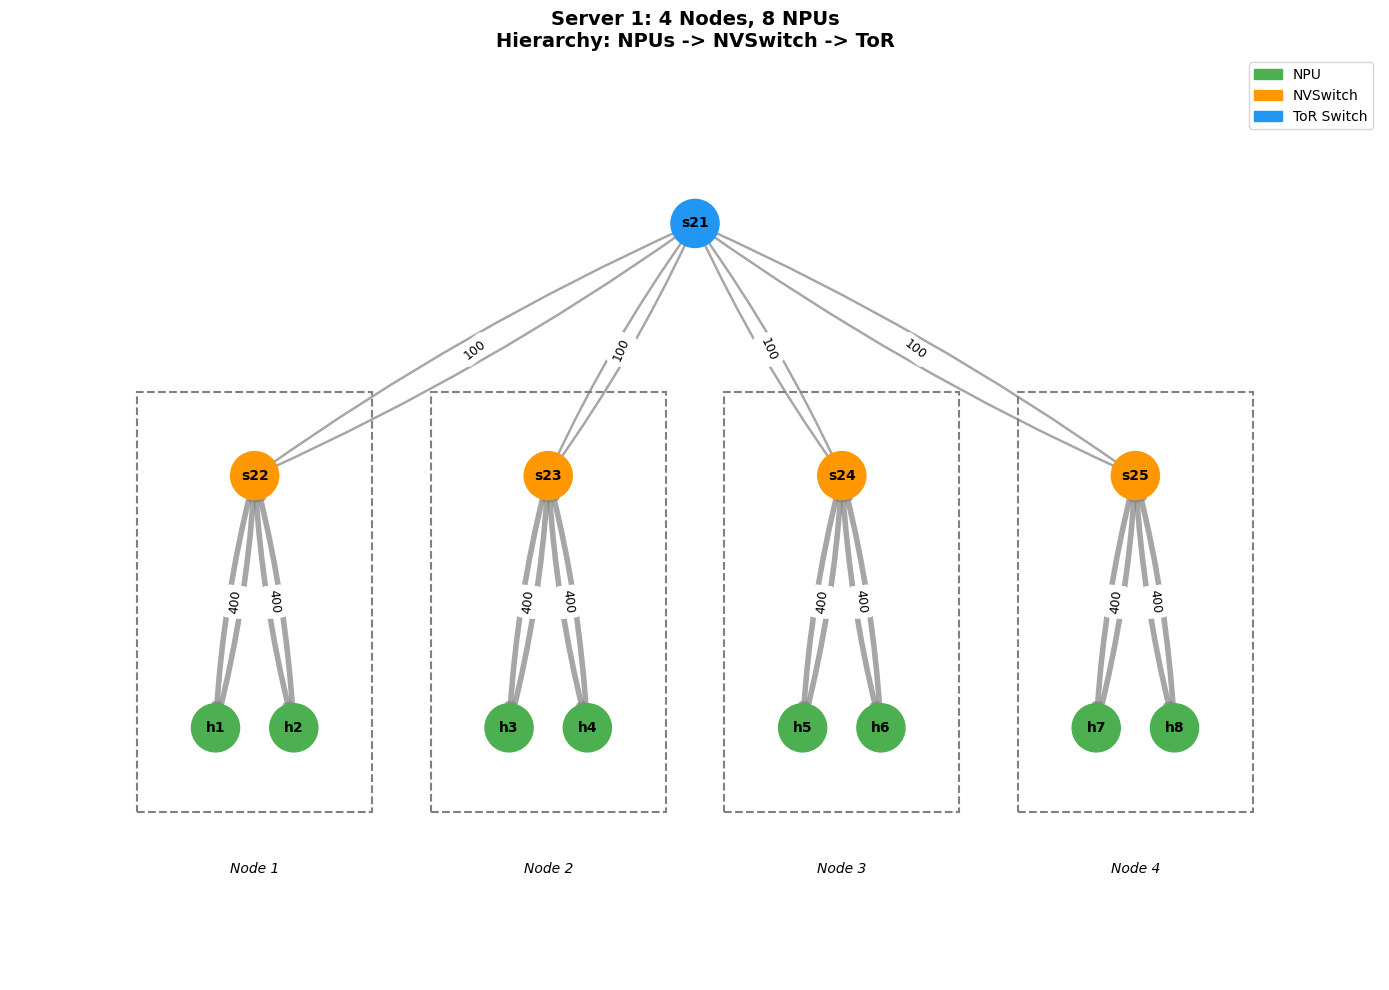

In [ ]:
# Folded-Clos with 3-Level Hierarchy
bw_config = {
    'host_edge': 100,         # Host to edge switch
    'edge_agg': 200,          # Edge to aggregation
    'agg_core': 200,          # Aggregation to core
    'intra_node': 400         # Within node (NPU to NVSwitch)
}

fc_3level = FoldedClos(
    K=4,                      # K=4 fat-tree
    bandwidth_config=bw_config,
    nodes_per_server=4,       # NEW: 2 nodes per server
    npus_per_node=2,          # 2 NPUs per node (smaller for visibility)
    intra_node_topology='switch',
    num_nvswitches=1
)

print(f"Folded-Clos Configuration:")
print(f"  - K: {fc_3level.K}")
print(f"  - Total servers: {fc_3level.total_num_servers}")
print(f"  - Nodes per server: {fc_3level.nodes_per_server}")
print(f"  - Total nodes: {fc_3level.total_num_nodes}")
print(f"  - NPUs per node: {fc_3level.npus_per_node}")
print(f"  - Total NPUs: {fc_3level.total_num_hosts}")

# Visualize a single server from the FoldedClos
visualize_single_server(fc_3level, server_idx=1)
plt.show()